In [ ]:
pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 5.5 MB/s  0:00:015.5 MB/s eta 0:00:0102
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 6.3 MB/s  0:00:01m 6.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.5 MB/s  0:00:00m 6.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s  0:00:00m 6.8 MB/s eta 0:00:01
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 12/17 [pydantic]quests-cache]
    Found existing installation: pandas 3.0.1╺━━━━━━━━━━━ 12/17 [pydantic]
    Uninstalling pandas-3.0.1:━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 12/17 [pydantic]
      Successfully uninstalled pandas-3.0.1━━╺━━━━━━━━━━━ 12/17 [pydantic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [fastf1]7m━━━━━━━ 14/17 [cryptography]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

In [7]:
print(f"Fast F1: {fastf1.__version__}")

Fast F1: 3.8.1


In [8]:
# Enabling the Cache...
import os

# Create a folder named 'cache' in your current directory
if not os.path.exists('cache'):
    os.makedirs('cache')

# Enable the cache
fastf1.Cache.enable_cache('cache')

In [11]:
session = fastf1.get_session(2026, 'Australia', 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

In [14]:
hamilton = session.laps.pick_driver('HAM')
fastestLap = hamilton.pick_fastest()

print(fastestLap)

Time                      0 days 02:21:35.071000
Driver                                       HAM
DriverNumber                                  44
LapTime                   0 days 00:01:22.423000
LapNumber                                   55.0
Stint                                        2.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:29.094000
Sector2Time               0 days 00:00:17.613000
Sector3Time               0 days 00:00:35.716000
Sector1SessionTime        0 days 02:20:41.848000
Sector2SessionTime        0 days 02:20:59.461000
Sector3SessionTime        0 days 02:21:35.177000
SpeedI1                                    252.0
SpeedI2                                    296.0
SpeedFL                                    303.0
SpeedST                                    316.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [15]:
telemetry = fastestLap.get_telemetry()

print(telemetry[['Distance', 'Speed', 'Throttle', 'Brake', 'nGear']].head(10))

     Distance       Speed    Throttle  Brake  nGear
2    0.060443  308.358334  100.000000  False      8
3   13.242222  309.000000  100.000000  False      8
4   17.919560  307.968749  100.000000  False      8
5   26.842222  306.000000  100.000000  False      8
6   34.974370  307.187501   99.703125  False      8
7   54.397778  310.000000   99.000000  False      8
8   59.154812  310.343750   99.171875  False      8
9   82.131111  312.000000  100.000000  False      8
10  90.495317  312.955224  100.000000  False      8
11  99.662778  314.000000  100.000000  False      8


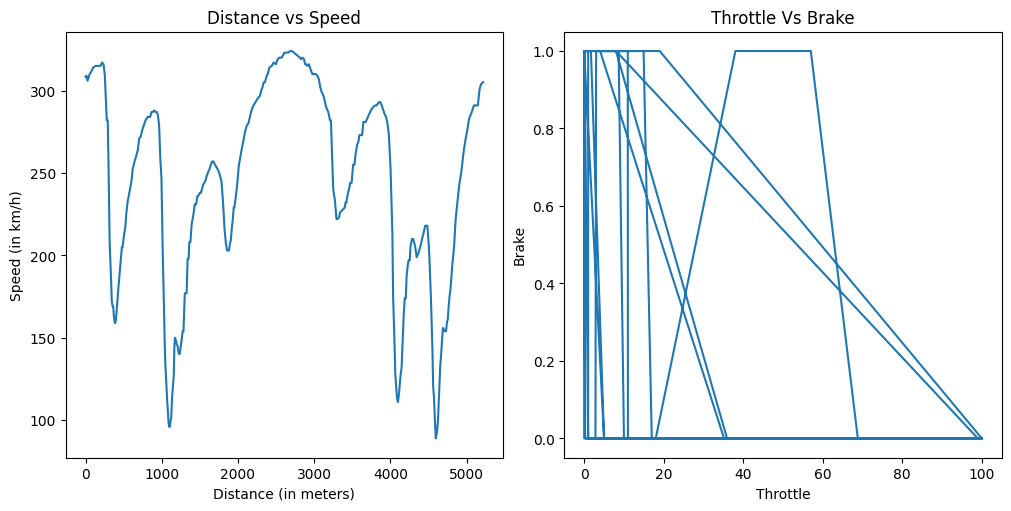

In [38]:
speed = telemetry['Speed']
dist = telemetry['Distance']
throttle = telemetry['Throttle']
brake = telemetry['Brake']

fig, ax = plt.subplots(1,2, figsize=(10,5), constrained_layout = True) # While constrained_layout works dynamically and better for complex layouts.

ax[0].plot(dist, speed)
ax[0].set_xlabel('Distance (in meters)')
ax[0].set_ylabel('Speed (in km/h)')
ax[0].set_title('Distance vs Speed')

ax[1].plot(throttle, brake)
ax[1].set_xlabel('Throttle')
ax[1].set_ylabel('Brake')
ax[1].set_title('Throttle Vs Brake')

# plt.tight_layout() #This is the same as constrained_layout, but it works after the graph have been created.
# plt.subplots_adjust(wspace = 0.4) # This is for the Horizontal spacing betweent the graphs...
plt.show()

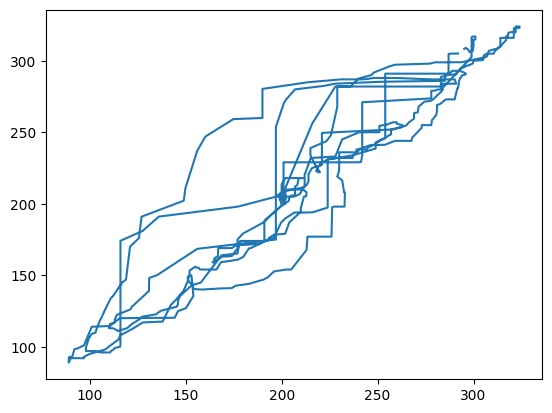

In [45]:
rus = session.laps.pick_drivers('RUS')
ham = session.laps.pick_drivers('HAM')
lec = session.laps.pick_drivers('LEC')

rus_fastlap = rus.pick_fastest()
ham_fastlap = ham.pick_fastest()

rus_tele = rus_fastlap.get_telemetry()
ham_tele = ham_fastlap.get_telemetry()

rus_tele_speed = rus_tele['Speed']
ham_tele_speed = ham_tele['Speed']

plt.plot(rus_tele_speed, ham_tele_speed)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

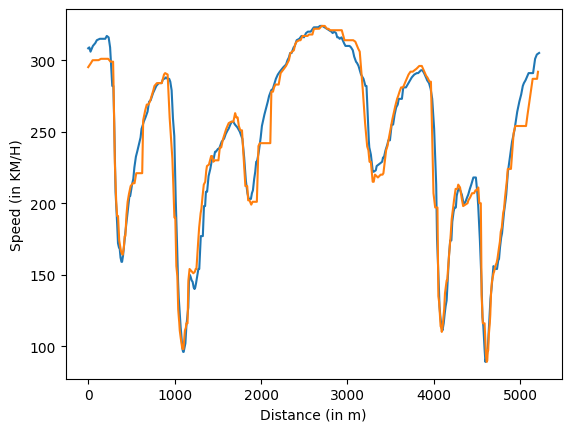

In [15]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fastf1 import plotting
plotting.setup_mpl()

session = fastf1.get_session(2026, 'Australia', 'R')
session.load(telemetry=True)

ham = session.laps.pick_drivers('HAM')
rus = session.laps.pick_drivers('RUS')

fastest_lap_ham = ham.pick_fastest()
fastest_lap_rus = rus.pick_fastest()


tele_ham = fastest_lap_ham.get_telemetry()
tele_rus = fastest_lap_rus.get_telemetry()


plt.plot(tele_ham['Distance'], tele_ham['Speed'])
plt.plot(tele_rus['Distance'],tele_rus['Speed'])
plt.xlabel("Distance (in m)")
plt.ylabel("Speed (in KM/H)")
plt.show()

In [4]:
results = session.results
print(results)

   DriverNumber BroadcastName Abbreviation        DriverId         TeamName  \
63           63     G RUSSELL          RUS         russell         Mercedes   
12           12   K ANTONELLI          ANT       antonelli         Mercedes   
16           16     C LECLERC          LEC         leclerc          Ferrari   
44           44    L HAMILTON          HAM        hamilton          Ferrari   
1             1      L NORRIS          NOR          norris          McLaren   
3             3  M VERSTAPPEN          VER  max_verstappen  Red Bull Racing   
87           87     O BEARMAN          BEA         bearman     Haas F1 Team   
41           41    A LINDBLAD          LIN  arvid_lindblad     Racing Bulls   
5             5   G BORTOLETO          BOR       bortoleto             Audi   
10           10       P GASLY          GAS           gasly           Alpine   
31           31        E OCON          OCO            ocon     Haas F1 Team   
23           23       A ALBON          ALB          

In [5]:
weather = session.weather_data
print(weather)

                      Time  AirTemp  Humidity  Pressure  Rainfall  TrackTemp  \
0   0 days 00:00:13.466000     23.1      55.8    1013.7     False       36.2   
1   0 days 00:01:13.482000     23.2      55.1    1013.6     False       35.9   
2   0 days 00:02:13.483000     23.2      55.2    1013.6     False       35.6   
3   0 days 00:03:13.485000     23.1      55.7    1013.7     False       35.7   
4   0 days 00:04:13.518000     23.1      55.8    1013.8     False       35.8   
..                     ...      ...       ...       ...       ...        ...   
143 0 days 02:23:14.291000     25.2      51.9    1011.5     False       34.6   
144 0 days 02:24:14.277000     25.2      52.0    1011.5     False       34.4   
145 0 days 02:25:14.290000     25.1      51.7    1011.5     False       34.5   
146 0 days 02:26:14.290000     25.0      52.2    1011.5     False       34.3   
147 0 days 02:27:14.318000     25.0      52.7    1011.5     False       34.5   

     WindDirection  WindSpeed  
0      

In [6]:
compound = session.laps.pick_compounds("SOFT")
print(compound)

                      Time Driver DriverNumber                LapTime  \
158 0 days 02:09:38.047000    PER           11 0 days 00:01:33.422000   
159 0 days 02:11:04.361000    PER           11 0 days 00:01:26.314000   
160 0 days 02:12:32.456000    PER           11 0 days 00:01:28.095000   
161 0 days 02:13:58.526000    PER           11 0 days 00:01:26.070000   
162 0 days 02:15:24.677000    PER           11 0 days 00:01:26.151000   
..                     ...    ...          ...                    ...   
860 0 days 02:20:22.807000    SAI           55 0 days 00:01:23.590000   
861 0 days 02:21:50.768000    SAI           55 0 days 00:01:27.961000   
862 0 days 02:23:15.034000    SAI           55 0 days 00:01:24.266000   
863 0 days 02:24:38.843000    SAI           55 0 days 00:01:23.809000   
864 0 days 02:26:03.666000    SAI           55 0 days 00:01:24.823000   

     LapNumber  Stint             PitOutTime PitInTime            Sector1Time  \
158       44.0    3.0 0 days 02:08:07.1240

In [33]:
car = session.car_data # To get the car data of the driver's car. This will return the dictionary. 
print(car['44'])


                         Date     RPM  Speed  nGear  Throttle  Brake  DRS  \
0     2026-03-08 03:08:39.840     0.0    0.0      0       0.0  False    0   
1     2026-03-08 03:08:40.240     0.0    0.0      0       0.0  False    0   
2     2026-03-08 03:08:40.400     0.0    0.0      0       0.0  False    0   
3     2026-03-08 03:08:40.560     0.0    0.0      0       0.0  False    0   
4     2026-03-08 03:08:40.840     0.0    0.0      0       0.0  False    0   
...                       ...     ...    ...    ...       ...    ...  ...   
31174 2026-03-08 05:28:36.188  7577.0  123.0      4      14.0  False    0   
31175 2026-03-08 05:28:36.428  7630.0  124.0      4      14.0  False    0   
31176 2026-03-08 05:28:36.667  7633.0  124.0      4      14.0  False    0   
31177 2026-03-08 05:28:36.827  7578.0  124.0      4      14.0  False    0   
31178 2026-03-08 05:28:37.147  7547.0  124.0      4      14.0  False    0   

      Source                   Time            SessionTime  
0        car 0

0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
          ...  
31174    7577.0
31175    7630.0
31176    7633.0
31177    7578.0
31178    7547.0
Name: RPM, Length: 31179, dtype: float64 0        0
1        0
2        0
3        0
4        0
        ..
31174    4
31175    4
31176    4
31177    4
31178    4
Name: nGear, Length: 31179, dtype: int64


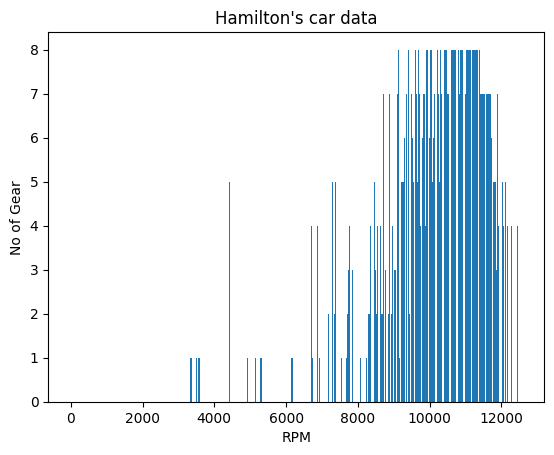

In [40]:
ham_car = car['44'] # getting the Hamilton's car (Key)
print(ham_car['RPM'], ham_car['nGear'])  # getting a particular column's data...

plt.bar(ham_car['RPM'], ham_car['nGear'])
plt.xlabel("RPM")
plt.ylabel("No of Gear")
plt.title("Hamilton's car data")
plt.show()

In [42]:
# To get the position of the Car... basically it gives the X and Y co-ordinates!!
pos = session.pos_data
ham_car_pos = pos['44']
print(ham_car_pos)

                         Date   Status       X       Y     Z Source  \
0     2026-03-08 03:08:04.681  OnTrack     0.0     0.0   0.0    pos   
1     2026-03-08 03:08:04.881  OnTrack     0.0     0.0   0.0    pos   
2     2026-03-08 03:08:05.141  OnTrack     0.0     0.0   0.0    pos   
3     2026-03-08 03:08:05.441  OnTrack     0.0     0.0   0.0    pos   
4     2026-03-08 03:08:05.741  OnTrack     0.0     0.0   0.0    pos   
...                       ...      ...     ...     ...   ...    ...   
32134 2026-03-08 05:28:36.181  OnTrack  6018.0  -776.0  94.0    pos   
32135 2026-03-08 05:28:36.461  OnTrack  6068.0  -834.0  94.0    pos   
32136 2026-03-08 05:28:36.621  OnTrack  6103.0  -876.0  94.0    pos   
32137 2026-03-08 05:28:36.861  OnTrack  6154.0  -941.0  95.0    pos   
32138 2026-03-08 05:28:37.221  OnTrack  6227.0 -1041.0  95.0    pos   

                        Time            SessionTime  
0     0 days 00:06:58.058000 0 days 00:06:58.058000  
1     0 days 00:06:58.258000 0 days 00:

In [56]:
# Getting the Circuit Information...
circuit = session.get_circuit_info()
cir_corners = circuit.corners
print(cir_corners)

rotation = circuit.rotation
print(rotation)

              X             Y  Number Letter       Angle     Distance
0  -3650.594482   1193.784180       1        -176.632730   353.883741
1  -3555.053223   1992.750244       2          -1.517007   436.700337
2  -7194.970215   7101.942383       3         162.258315  1082.289274
3  -5878.734375   7709.864746       4         -23.426263  1240.170991
4  -5870.662598   9676.805664       5         159.215959  1435.149386
5  -2280.641357  11861.559570       6          96.736266  1864.705500
6  -1296.382446  11398.008789       7        -104.065903  1987.203085
7    502.412537  10576.311523       8          39.145642  2157.206134
8   2838.843750    798.959839       9        -101.197334  3279.161824
9   3973.896484    855.019897      10          73.476771  3383.648575
10  7489.130859  -4851.345215      11         -15.779635  4087.765440
11  5020.217773  -5538.887695      12        -106.082895  4359.092824
12  3587.226562  -3634.000000      13          89.839297  4608.497211
13  2300.284180  -44

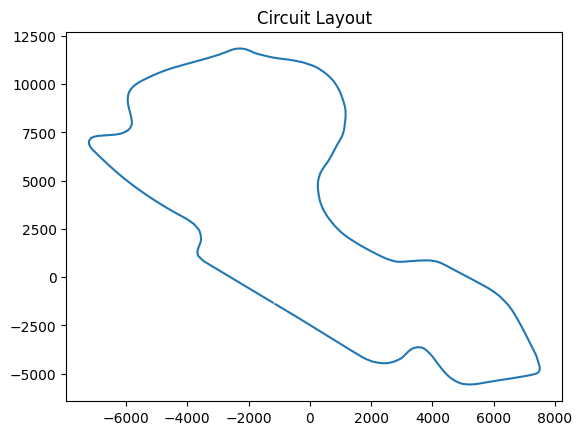

In [52]:
# To draw the circuit map!!
lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

plt.plot(tel["X"], tel["Y"])
plt.title("Circuit Layout")
plt.show()

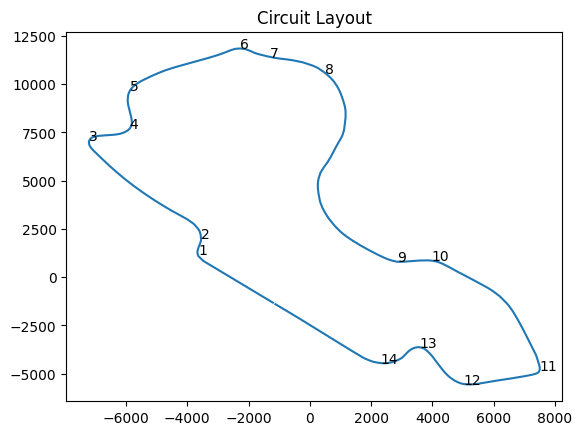

In [59]:
# To draw the Circuit map with corner labels...!
for _, corner in circuit.corners.iterrows():
    plt.text(corner['X'], corner['Y'], corner['Number'])

lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

plt.plot(tel["X"], tel["Y"])
plt.title("Circuit Layout")
plt.show()

In [77]:
# Building the China Circuit Map!!

# Load the session
china_session = fastf1.get_session(2026, 'China', 'FP1')
china_session.load()

core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '7

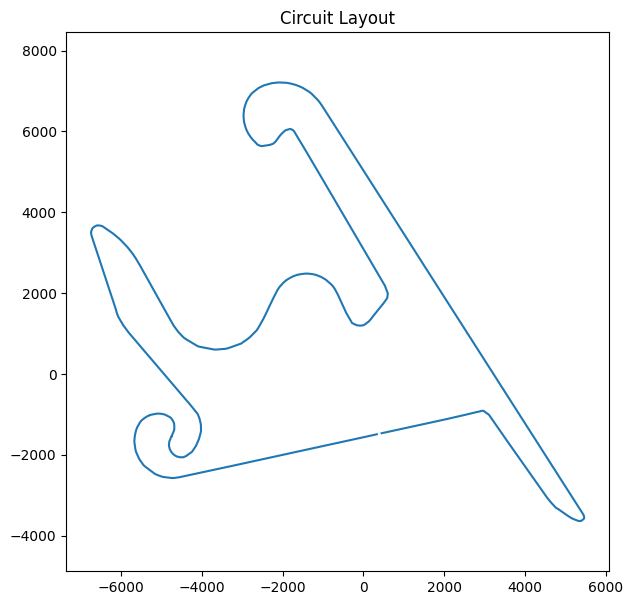

In [81]:
laps = china_session.laps.pick_fastest()
tele = laps.get_telemetry().sort_values(by="Distance")

plt.figure(figsize=(7,7))
plt.plot(tele["X"], tele["Y"])

plt.title("Circuit Layout")
plt.axis("equal")   # important
plt.show()

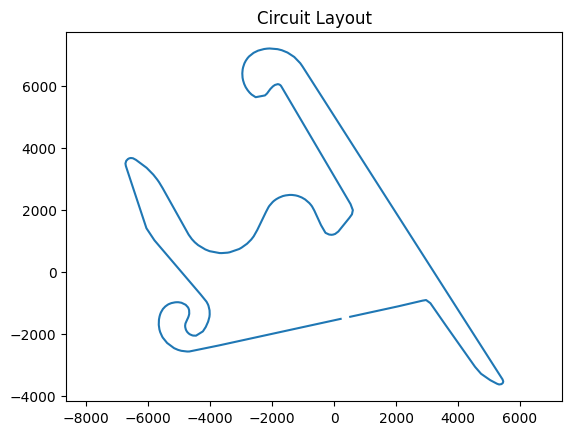

In [84]:
# Building the Circuit through pos data function from fastf1 api! This is more accurate!
laps = china_session.laps.pick_fastest()

pos = laps.get_pos_data()

x = pos['X']
y = pos['Y']

plt.plot(x,y)
plt.title("Circuit Layout")
plt.axis("equal")
plt.show()

In [103]:
# Plotting the Austrialian GP'26 Circuit showing the fast and slow areas of the circuit.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

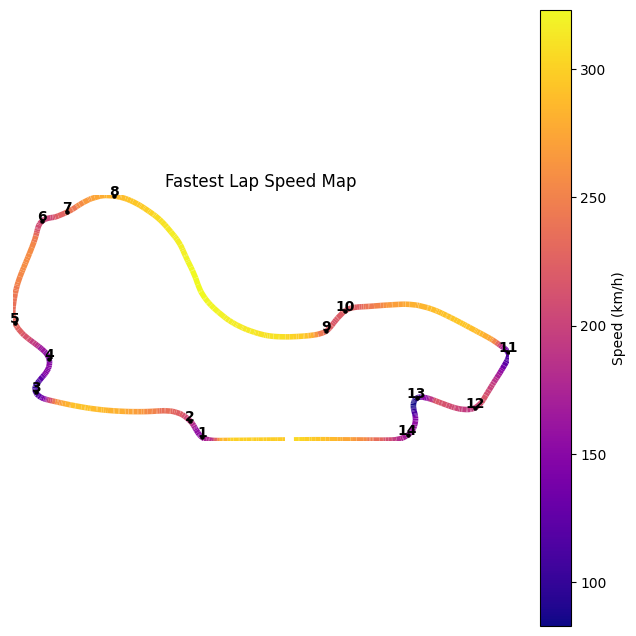

In [107]:
import fastf1
import fastf1.plotting
import numpy as np
import matplotlib.pyplot as plt # This only allows one color per line.
from matplotlib.collections import LineCollection # Allows you to draw a line that can have multiple colors along its length.
from matplotlib import cm # cm(color-maps); Provides color gradients, e.g., plasma or viridis. We need different shades to highlight areas.

# Enable plotting settings
fastf1.plotting.setup_mpl()

# Load session
session = fastf1.get_session(2026, "Australia", "R")
session.load()

# Get fastest lap
lap = session.laps.pick_fastest()

# Get telemetry and position data
car_data = lap.get_car_data().add_distance() # The .add_distance() converts the time-based data into the track-position data.
pos_data = lap.get_pos_data()

# Merge telemetry channels
telemetry = car_data.merge_channels(pos_data) # The .merge_channels() merges two dataframes according to the nearest possible timeframe. 
# So that we can plot the X,Y,Speed along the car's position on track.

# Remove rows with missing data
telemetry = telemetry.dropna(subset=["X", "Y", "Speed"]) # After merging,some rows may have missing values (NaN) because timestamps didn’t perfectly align.

# Extract arrays
x = telemetry["X"].to_numpy() #Converting Pandas into Numpy because Line Collection works best and efficiently on Numpy than Pandas.
y = telemetry["Y"].to_numpy()
speed = telemetry["Speed"].to_numpy()

# Get circuit info
circuit = session.get_circuit_info() 
angle = np.deg2rad(circuit.rotation) # To Make the CIRCUIT look North-Up!

# Rotate track
rot_x = x*np.cos(angle) - y*np.sin(angle) # X' = X cosQ - Y sinQ
rot_y = x*np.sin(angle) + y*np.cos(angle) # Y' = X sinQ + Y cosQ

# Create line segments
points = np.array([rot_x, rot_y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create colored line
norm = plt.Normalize(speed.min(), speed.max())
lc = LineCollection(segments, cmap=cm.plasma, norm=norm)
lc.set_array(speed)
lc.set_linewidth(4)

# Plot
fig, ax = plt.subplots(figsize=(8,8))
ax.add_collection(lc)

# Set axis limits because LineCollection does not automatically set axis limits (unlike plt.plot). Without this, the graph will break.
ax.set_xlim(rot_x.min(), rot_x.max()) 
ax.set_ylim(rot_y.min(), rot_y.max())

ax.set_aspect("equal")
ax.axis("off")

# Color bar
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label("Speed (km/h)")

# Plot corner numbers
for _, corner in circuit.corners.iterrows():
    cx = corner['X']*np.cos(angle) - corner['Y']*np.sin(angle)
    cy = corner['X']*np.sin(angle) + corner['Y']*np.cos(angle)

    ax.text(cx, cy, str(corner['Number']),
            color="black", fontsize=10, ha="center", weight = "bold")
    ax.scatter(cx, cy, color='black', s=5, zorder=15)

plt.title("Fastest Lap Speed Map")
plt.show()